# 1. Aproximación de $x^{-3}((\sin x) - x)$ basada en serie de taylor


Partiendo de la serie de Taylor del seno que iterativamente nos permitirá encontrar una aproximación a $\sin x$:
$\sin x = \sum_{i=0}^{\infty} \frac{(-1)^i\, x^{2i+1}}{(2i+1)!}$

<!-- Se tiene que:
$\sin x - x = \sum_{i=1}^{\infty} \frac{(-1)^i\, x^{2i+1}}{(2i+1)!}$ -->
Podremos obtener una aproximación a $f(x) = x^{-3}((\sin x) - x)$ mediante la proximación por la serie de taylor de $\sin x$ implementada en julia con recurrencia, luego simplemente le restamos el valor x y dividimos el resultado por $x^3$ (con $x \neq 0$):

$f(x) = \frac{(\sin x) - x}{x^{3}} = \frac{(\sum_{i=0}^{\infty} \frac{(-1)^{i}\, x^{2i +1}}{(2i+1)!})-x}{x^{3}}$


## 1.1. Implementaciones con precisión configurable

Las funcione implementadas reciben un string que indica la precisión con la cual trabajar:
- `"Float16"` → 16 bits (~3 dígitos decimales, épsilon de máquina ≈ 4.88e-4)
- `"Float32"` → 32 bits (~7 dígitos decimales, épsilon de máquina ≈ 1.19e-7)
- `"Float64"` → 64 bits (~15 dígitos decimales, épsilon de máquina ≈ 2.22e-16)

**Todos** los cálculos internos (constantes, acumuladores, operaciones) se realizan
en el tipo indicado, de modo que los errores de redondeo y representación son
exactamente los propios de esa aritmética.


In [68]:
# definimos algunas constantes de "configuración" de nuestros algoritmos
const MAX_ITERATIONS = 1000
const ANGULOS_PRUEBA = [30, 390, 750, 1110, 1470, 1830, 2190, 2550]

8-element Vector{Int64}:
   30
  390
  750
 1110
 1470
 1830
 2190
 2550

### 1.1.1. Implementación de $\sin x$ con precisión configurable

In [69]:
function sin_aprox(a, tol, precision="Float64", max_iterations = MAX_ITERATIONS)
    # Seleccionamos el tipo numérico según el string que indica la precisión
    T = if precision == "Float32"
            Float32
        elseif precision == "Float64"
            Float64
        else
            error("Precisión no reconocida: '$precision'. Usa \"Float32\" o \"Float64\".")
        end

    # Convertimos los grados a radianes en la precisión parametrizada (T)
    x = T(T(a) / T((T(180) / T(pi))))
    
    # Convertimos las constantes y la entrada a la presición parametrizada (T)
    res = T(x)
    term = T(x)
    denom = T(3.0)
    x_cuad = T(x ^ T(2))
    tol_T = T(tol)

    # Recolectamos información para entender qué sucedió en la ejecución del algoritmo
    converged = false
    count_iterations = 0


    for _ in 1:max_iterations
        # -(x*x²)/3*(2)
        term = T(T( (-1) * T(term * x_cuad)) / T((denom) * T(denom - T(1))))
        res = T(res + term)

        count_iterations += 1

        if (abs(term) < tol_T)
            converged = true
            break
        end
        
        denom = denom + T(2)
        
    end

    if !converged
        println("[WARNING]: Terminó por máximo de iteraciones ($max_iterations)")
    else
        println("[INFO]: Convergió en $count_iterations iteraciones")
    end

    return (res, count_iterations)
end


sin_aprox (generic function with 3 methods)

### 1.1.2. Implementación de $f(x) = x^{-3}((\sin x) - x)$ con precisión configurable
Hacemos uso de la función anterior de la siguiente forma

In [70]:
function f_aprox(a, tol, precision="Float64", max_iterations = MAX_ITERATIONS)
    # Seleccionamos el tipo numérico según el string que indica la precisión
    T = if precision == "Float32"
            Float32
        elseif precision == "Float64"
            Float64
        else
            error("Precisión no reconocida: '$precision'. Usa \"Float32\" o \"Float64\".")
        end
    sin_res, count_iterations = sin_aprox(a, tol, precision, max_iterations)

    # Convertimos los grados a radianes en la precisión parametrizada (T)
    x = T(T(a) / T((T(180) / T(pi))))

    # Verifiquemos que no se esté por tratar de dividir entre 0
    denom =T(x^T(3))
    
    if denom == 0
        error("Expresión contiene denominador igual a cero: $(denom). Error.")
    end
    
    # Obtenemos el valor final
    res = T(T(sin_res - x)/denom)
    return res

end


f_aprox (generic function with 3 methods)

### 1.1.3. Implementación de $f(\frac{x\times \pi}{2}) = (\frac{x\times \pi}{2})^{-3}((\sin (\frac{x\times \pi}{2})) - \frac{x\times \pi}{2})$
Reutilizamos la función anterior, es decir, armamos una funcion _wrapper_ de la función previamente implementada.

In [71]:
function f_aprox_wrapper(a, tol, precision="Float64", max_iterations = MAX_ITERATIONS)
    return f_aprox((a*pi)/2, tol, precision,max_iterations)
end

f_aprox_wrapper (generic function with 3 methods)

## 1.2. Tablas comparativas de resultados por precisión

### 1.2.1. Dependencias
Se usa [`PrettyTables.jl`](https://github.com/ronisbr/PrettyTables.jl) para mostrar, para $f(x)$ y para $f(\frac{x\pi}{2})$, tablas con los valores de referencia y los errores absolutos de cada precisión para los ángulos de interés (definidos como `ANGULOS_PRUEBA`).

In [72]:
# importamos librería para construir tablas legibles
import Pkg; 
Pkg.add("PrettyTables")
Pkg.status("PrettyTables")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


Status `~/.julia/environments/v1.10/Project.toml`
  [08abe8d2] PrettyTables v3.3.2


### 1.2.2. Función que toma dos funciones (aprox y referencia) y muestra tabla con valores
Definimos la función `tabla_resultados_y_errores_de_aproximaciones` la cual toma como argumentos dos funciones, una que debe de darnos una aproximación con la precisión indicada y otra que debe de brindar el valor de referencia provisto por Julia, luego solo hacemos diferentes llamados para los mismos angulos cambiando la precisión, calculamos otros datos como el error relativo de cada aproxmación (con respecto al valor de referencia) y renderizamos en una tabla.

In [73]:
using Printf
using PrettyTables

# definimos función que recibe una función (implementación de f(x) o f(x*pi/2)), la llama para los angulos definidos como ANGULOS_PRUEBA
# y finalmente formatea los resultados en una tabla legible.
function tabla_resultados_y_errores_de_aproximaciones(funcion_aproximada, funcion_referencia, tol=1e-6, angulos = ANGULOS_PRUEBA)
    # Calculamos los valores de referencia provistos por julia
    referencias = [Float64(funcion_referencia(a)) for a in angulos]

    # Calculamos valores llamando para las precisiones f32 y f64
    f32_results = [Float32(funcion_aproximada(a, tol, "Float32")) for a in angulos]
    f64_results = [Float64(funcion_aproximada(a, tol, "Float64")) for a in angulos]

    # Calculamos errores absolutos de cada aproximación
    err32 = [abs(x - ref) for (x, ref) in zip(f32_results, referencias)]
    err64 = [abs(x - ref) for (x, ref) in zip(f64_results, referencias)]
    
    # Armamos la tabla
    data = hcat(angulos, referencias, f32_results, f64_results, err32, err64)

    pretty_table(
        data,
        backend       = :html,
        column_labels = [
            "Ángulo (°)", "Referencia (BigFloat)", "Float32", "Float64", "Err abs. F32", "Err abs. F64"
        ],
        formatters = [(v, i, j) -> j in 2:8 ? @sprintf("%.6e", v) : v],
        alignment  = [:r, :r, :r, :r, :r, :r],
    )
    # Retornamos los errores encontrados para poder reutilizarlos
    return (err32, err64)
    
end


tabla_resultados_y_errores_de_aproximaciones (generic function with 3 methods)

### 1.2.3. Tabla comparativa para $f(x) = x^{-3}((\sin x) - x)$
Llamamos a la función previamente definida con las funciones adecuadas para obtener la tabla que compare los valores que nuestra aproximación retorna para $f(x)$ con los que Julia provee.

In [74]:
# Esta es la función que nos dará el valor de referencia para f(x) 
function f_ref_1(a)
    xb = BigFloat(a) / (BigFloat(180) / BigFloat(pi))
    (sin(xb) - xb) / xb^3
end

f_ref_1 (generic function with 1 method)

In [75]:
# Construcción de tabla
# Almacenamos los errores encontrados para poder usarlos después
err32_f1, err64_f1 = tabla_resultados_y_errores_de_aproximaciones(f_aprox, f_ref_1, 1e-6, ANGULOS_PRUEBA)


[INFO]: Convergió en 4 iteraciones
[INFO]: Convergió en 14 iteraciones
[INFO]: Convergió en 23 iteraciones
[INFO]: Convergió en 31 iteraciones
[INFO]: Convergió en 40 iteraciones
[INFO]: Convergió en 48 iteraciones
[INFO]: Convergió en 57 iteraciones
[INFO]: Convergió en 66 iteraciones
[INFO]: Convergió en 4 iteraciones
[INFO]: Convergió en 14 iteraciones
[INFO]: Convergió en 23 iteraciones
[INFO]: Convergió en 31 iteraciones
[INFO]: Convergió en 40 iteraciones
[INFO]: Convergió en 48 iteraciones
[INFO]: Convergió en 57 iteraciones
[INFO]: Convergió en 66 iteraciones


Ángulo (°),Referencia (BigFloat),Float32,Float64,Err abs. F32,Err abs. F64
30.0,-1.643969e-01,-1.643970e-01,-1.643969e-01,7.912554e-08,1.412768e-10
390.0,-1.999779e-02,-1.999783e-02,-1.999779e-02,3.607202e-08,2.446908e-11
750.0,-5.613178e-03,-5.613427e-03,-5.613178e-03,2.491061e-07,3.686922e-12
1110.0,-2.595634e-03,-2.589348e-03,-2.595634e-03,6.286265e-06,6.917029e-12
1470.0,-1.489578e-03,2.268247e-03,-1.489578e-03,3.757826e-03,8.015344e-11
1830.0,-9.649184e-04,-4.649596e+00,-9.649350e-04,4.648631e+00,1.656954e-08
2190.0,-6.755204e-04,2.684432e+03,-6.777074e-04,2.684433e+03,2.187082e-06
2550.0,-4.991812e-04,4.884278e+05,-1.228330e-03,4.884278e+05,7.291490e-04


([7.912554217393009e-8, 3.607202178276814e-8, 2.491060862907027e-7, 6.286265028411855e-6, 0.003757825647227804, 4.648630819012296, 2684.4328044266126, 488427.7504991812], [1.4127676806197087e-10, 2.446908300979267e-11, 3.6869222952429226e-12, 6.917029015535148e-12, 8.015344009175418e-11, 1.656954131735479e-8, 2.1870817235099694e-6, 0.0007291490441183672])

### 1.2.4. Tabla comparativa para $f(\frac{x \times \pi}{2})$
De manera similar, primero definimos la función que retorna el valor de referencia provisto por Julia y luego llamamos con las funciones adecuadas a `tabla_resultados_y_errores_de_aproximaciones`

In [76]:
function f_ref_2(a)
    xb = BigFloat(a) / (BigFloat(180) / BigFloat(pi))
    (sin(xb) - xb)*pi / ((xb^3)*2)
end

f_ref_2 (generic function with 1 method)

In [77]:
# Construcción de tabla
# Almacenamos los errores para poder usarlos después
err32_f2, err64_f2 = tabla_resultados_y_errores_de_aproximaciones(f_aprox_wrapper, f_ref_2, 1e-6, ANGULOS_PRUEBA)

[INFO]: Convergió en 4 iteraciones
[INFO]: Convergió en 19 iteraciones
[INFO]: Convergió en 33 iteraciones
[INFO]: Convergió en 46 iteraciones
[INFO]: Convergió en 60 iteraciones
[INFO]: Convergió en 73 iteraciones
[INFO]: Convergió en 87 iteraciones
[INFO]: Convergió en 100 iteraciones
[INFO]: Convergió en 4 iteraciones
[INFO]: Convergió en 19 iteraciones
[INFO]: Convergió en 33 iteraciones
[INFO]: Convergió en 46 iteraciones
[INFO]: Convergió en 60 iteraciones
[INFO]: Convergió en 73 iteraciones
[INFO]: Convergió en 87 iteraciones
[INFO]: Convergió en 100 iteraciones


Ángulo (°),Referencia (BigFloat),Float32,Float64,Err abs. F32,Err abs. F64
30.0,-2.582340e-01,-1.611194e-01,-1.611195e-01,9.711465e-02,9.711453e-02
390.0,-3.141246e-02,-9.528277e-03,-9.528069e-03,2.188418e-02,2.188439e-02
750.0,-8.817159e-03,-1.901392e-03,-2.251396e-03,6.915767e-03,6.565763e-03
1110.0,-4.077212e-03,2.541947e+00,-1.109401e-03,2.546024e+00,2.967811e-03
1470.0,-2.339824e-03,-1.677303e+04,-5.366342e-04,1.677303e+04,1.803190e-03
1830.0,-1.515690e-03,1.033868e+08,4.669605e-02,1.033868e+08,4.821174e-02
2190.0,-1.061105e-03,1.675024e+12,-1.683212e+03,1.675024e+12,1.683211e+03
2550.0,-7.841120e-04,1.252301e+16,3.354123e+07,1.252301e+16,3.354123e+07


([0.09711464806822806, 0.02188418020507784, 0.006915766584969349, 2.546023861962931, 16773.028910175814, 1.0338682400151569e8, 1.675024007168001e12, 1.252301331234816e16], [0.09711452999055115, 0.021884388188133576, 0.006565763100185185, 0.0029678110018787882, 0.0018031900038959826, 0.04821173747764028, 1683.2112779140512, 3.3541234438682623e7])

## 1.3. Gráficos de errores absolutos en función del ángulo indicado
Para visualizar de mejor forma la evolución y comportamiento de nuestras aproximaciones renderizaremos en gráficos que nos permitan comparar los errores absolutos de nuestras aproximaciones trabajadas con precisión `Float32` y `Float64` respectivamente

### 1.3.1. Dependencias

In [78]:
import Pkg; Pkg.add("Plots")
Pkg.status("Plots")


   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


Status `~/.julia/environments/v1.10/Project.toml`
  [91a5bcdd] Plots v1.41.6


### 1.3.2. Errores absolutos para $f(x)$ 

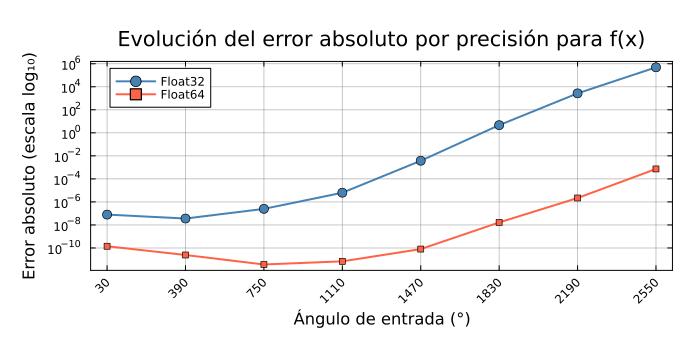

In [79]:
using Plots
using Plots.PlotMeasures

gr()

plot(ANGULOS_PRUEBA, err32_f1;
    label         = "Float32",
    color         = :steelblue,
    lw            = 2,
    marker        = :circle,
    markersize    = 5,
    yscale        = :log10,
    yticks        = [ 1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6, 1e8],
    xlabel        = "Ángulo de entrada (°)",
    ylabel        = "Error absoluto (escala log₁₀)",
    title         = "\nEvolución del error absoluto por precisión para f(x)",
    legend        = :topleft,
    framestyle    = :box,
    grid          = true,
    gridalpha     = 0.3,
    gridlinewidth = 0.8,
    gridcolor     = :gray,
    size = (700, 340),
    xticks        = ANGULOS_PRUEBA,
    xrotation     = 45,
    bottom_margin = 7mm,
    left_margin   = 7mm,
    right_margin = 5mm,
    top_margin = 7mm,

)

plot!(ANGULOS_PRUEBA, err64_f1;
    label      = "Float64",
    color      = :tomato,
    lw         = 2,
    marker     = :square,
    markersize = 3,
)

### 1.3.3. Errores absolutos para $f(\frac{x \times \pi}{2})$

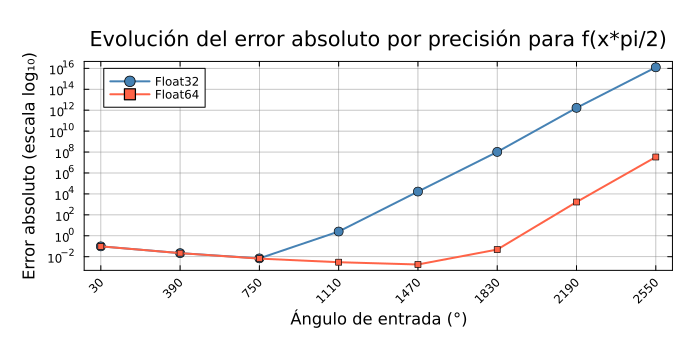

In [80]:
using Plots
using Plots.PlotMeasures

gr()

plot(ANGULOS_PRUEBA, err32_f2;
    label         = "Float32",
    color         = :steelblue,
    lw            = 2,
    marker        = :circle,
    markersize    = 5,
    yscale        = :log10,
    yticks        = [ 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6, 1e8, 1e10, 1e12, 1e14, 1e16, 1e18],
    xlabel        = "Ángulo de entrada (°)",
    ylabel        = "Error absoluto (escala log₁₀)",
    title         = "\nEvolución del error absoluto por precisión para f(x*pi/2)",
    legend        = :topleft,
    framestyle    = :box,
    grid          = true,
    gridalpha     = 0.3,
    gridlinewidth = 0.8,
    gridcolor     = :gray,
    size = (700, 340),
    xticks        = ANGULOS_PRUEBA,
    xrotation     = 45,
    bottom_margin = 7mm,
    left_margin   = 7mm,
    right_margin = 5mm,
    top_margin = 7mm,

)

plot!(ANGULOS_PRUEBA, err64_f2;
    label      = "Float64",
    color      = :tomato,
    lw         = 2,
    marker     = :square,
    markersize = 3,
)

## 1.4. Gráficos de errores relativos en función del ángulo indicado

### 1.4.1. Gráfico para visualizar errores relativos por ángulo de $f(x)$
El error relativo normaliza el error absoluto respecto al valor de referencia, permitiendo comparar la precisión independientemente de la magnitud de `f(x)`.

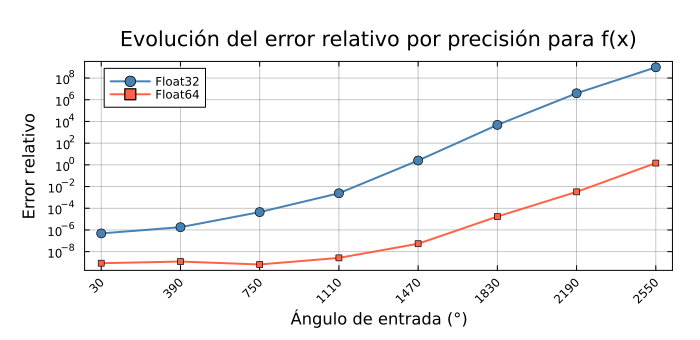

In [81]:
referencias_1 = [f_ref_1(a) for a in ANGULOS_PRUEBA]
# Calculamos los errores relativos respecto a las aproximaciones de f(x) dividiendo los errores relativos por las reerencias
err32_rel_1 = err32_f1 ./ abs.(referencias_1)
err64_rel_1 = err64_f1 ./ abs.(referencias_1)

plot(ANGULOS_PRUEBA, err32_rel_1;
    label         = "Float32",
    color         = :steelblue,
    lw            = 2,
    marker        = :circle,
    markersize    = 5,
    yscale        = :log10,
    yticks        = [1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6, 1e8, 1e10],
    xlabel        = "Ángulo de entrada (°)",
    ylabel        = "Error relativo",
    title         = "\nEvolución del error relativo por precisión para f(x)",
    legend        = :topleft,
    framestyle    = :box,
    grid          = true,
    gridalpha     = 0.3,
    gridlinewidth = 0.8,
    gridcolor     = :gray,
    size = (700, 340),
    xticks        = ANGULOS_PRUEBA,
    xrotation     = 45,
    bottom_margin = 7mm,
    left_margin   = 7mm,
    right_margin = 5mm,
    top_margin = 7mm,
)

plot!(ANGULOS_PRUEBA, err64_rel_1;
    label      = "Float64",
    color      = :tomato,
    lw         = 2,
    marker     = :square,
    markersize = 3,
)

### 1.4.2. Gráfico para visualizar errores relativos por ángulo de $f(\frac{x. \pi}{2})$
El error relativo normaliza el error absoluto respecto al valor de referencia, permitiendo comparar la precisión independientemente de la magnitud de $f(\frac{x. \pi}{2})$.

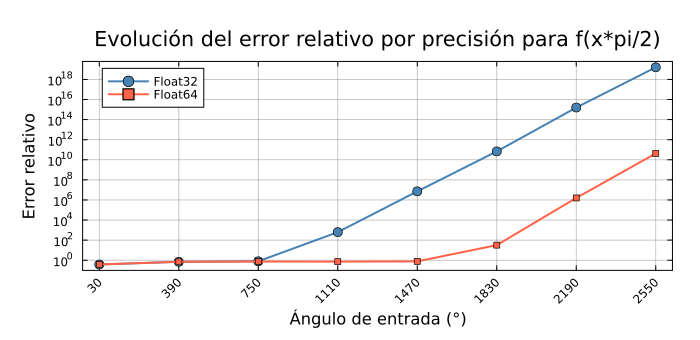

In [83]:
referencias_2 = [f_ref_2(a) for a in ANGULOS_PRUEBA]
# Calculamos los errores relativos respecto a las aproximaciones de f(x*pi/2) dividiendo los errores relativos por las referencias
err32_rel_2 = err32_f2 ./ abs.(referencias_2)
err64_rel_2 = err64_f2 ./ abs.(referencias_2)

plot(ANGULOS_PRUEBA, err32_rel_2;
    label         = "Float32",
    color         = :steelblue,
    lw            = 2,
    marker        = :circle,
    markersize    = 5,
    yscale        = :log10,
    yticks        = [ 1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6, 1e8, 1e10, 1e12, 1e14, 1e16, 1e18, 1e20],
    xlabel        = "Ángulo de entrada (°)",
    ylabel        = "Error relativo",
    title         = "\nEvolución del error relativo por precisión para f(x*pi/2)",
    legend        = :topleft,
    framestyle    = :box,
    grid          = true,
    gridalpha     = 0.3,
    gridlinewidth = 0.8,
    gridcolor     = :gray,
    size = (700, 340),
    xticks        = ANGULOS_PRUEBA,
    xrotation     = 45,
    bottom_margin = 7mm,
    left_margin   = 7mm,
    right_margin = 5mm,
    top_margin = 7mm,
)

plot!(ANGULOS_PRUEBA, err64_rel_2;
    label      = "Float64",
    color      = :tomato,
    lw         = 2,
    marker     = :square,
    markersize = 3,
)